# E85 · Market structure from purchase incidence: combining panel, activity and demographic data

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: 84.51's **"The Complete Journey"** (2,469 households' grocery shopping at one retailer in 2017; CC0, via the R package completejourney), reduced to the data a market-structure study usually gets: a **household x product 0/1 table** of which of 14 cold cereals (anonymised manufacturer x kids / family / adult segment, including the store's own brand) each household bought in **January-June**; each household's number of **shopping trips**; **demographics for only a third** of the households; and the same table for **July-December** as a real out-of-sample test |
| **You will learn** | What a 6-month **incidence** table can and cannot tell you about market structure (no prices, no sequences: *shared clientele*, not diversion) · why raw **co-purchase lift** says every product is related to every other (heavy shoppers buy everything) · a ladder of **Bernoulli-logit latent factor models**: activity, a household **category propensity**, then a **choice map** of household tastes · a naive factor model whose first dimension is just "buys a lot" · combining data sources with partial overlap: demographics in the **prior mean** of the household's map position, a **missing-data indicator**, and why demographics are **not missing at random** here · **complete-case analysis** vs using every household · rotation-free summaries: the **shared-clientele matrix**, a tree with posterior support, and a **manufacturer-vs-segment** comparison · how much demographics explain (little) and where they still help · validating on the **next six months** · a **trial-coupon targeting** decision scored on what households actually did next |

## The data you usually get

E84 had the luxury of a full purchase history: every trip, in order, with the shelf price of every
product. Many market-structure studies get far less. A typical consumer-panel extract is a table with
**one row per household and one column per product, holding 1 if the household bought the product at
least once in a period** (often six months), next to a demographic file for the panel members, and
perhaps the household's overall shopping activity. No prices, no dates, no quantities.

This notebook builds that situation from a real grocery panel and asks how far it can take us.

| source | what it holds | coverage |
|---|---|---|
| **incidence panel** (Jan-Jun 2017) | household x 14 cereal products, 0/1 | 2,391 households with a trip |
| **shopping activity** | trips (all departments) per household | all of them |
| **demographics** | age, income, household composition, kids | 801 households (a third) |
| **next wave** (Jul-Dec 2017) | the same incidence table | used only to test predictions |

The products are cells of **manufacturer x segment** in the retailer's cold-cereal category: four
anonymised national manufacturers (M194, M794, M1046, M584) and the store's own brand ("Store"), each in
up to three segments (kids, family, adult cereals) - 14 products covering 99.5% of cereal purchases.
The classic question returns from E84 in a new form: **is this market organised by manufacturer or by
segment, and where does the store brand sit?** The decision at the end is practical: **the retailer
wants to send a trial coupon for its store-brand kids' cereal; which households should get it?**

## The plan

1. The sources, how they overlap, and what is missing
2. Raw co-purchase: why everything looks related
3. A ladder of models: activity, propensity, a choice map
4. Adding demographics without throwing households away
5. Testing on the next six months
6. The market structure: shared clientele
7. What demographics explain
8. Targeting a trial coupon

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import xarray as xr
from scipy import special, stats
from scipy.cluster import hierarchy

from pymc_challenges import data

RANDOM_SEED = 85
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def q(x, probs=(0.05, 0.5, 0.95), axis=None):
    """Posterior quantiles, rounded for printing."""
    return np.round(np.quantile(x, probs, axis=axis), 2)

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


---
# 1 · The sources and how they overlap

In [2]:
for name in ["cj_cereal_incidence", "cj_activity", "cj_demographics"]:
    data.describe(name)
inc = data.load("cj_cereal_incidence")
act = data.load("cj_activity")
dem = data.load("cj_demographics")
PRODUCTS = list(inc.columns[2:])
J = len(PRODUCTS)
inc = inc.merge(act, on=["household_id", "half"])
h1 = inc[inc["half"] == 1].reset_index(drop=True)
hh = h1["household_id"].to_numpy()
H = len(hh)
Y1 = h1[PRODUCTS].to_numpy()
h1.head()

cj_cereal_incidence: Half-year purchase incidence of cold cereals, the format panel providers deliver: household_id, half (1 = weeks 1-26 of 2017, 2 = weeks 27-53) for every household with a shopping trip in that half, and 0/1 columns for 14 cereal products = manufacturer x segment (M194_family = manufacturer 194's all-family cereals; manufacturers are anonymised; Store = the retailer's own brand; segments kids, family, adult), 1 if bought at least once in the half.
  source: 84.51, 'The Complete Journey' (2017 grocery transactions of 2,469 households at one retailer), distributed as the R package completejourney (Boehmke, Davis & Delaney; CC0 1.0; the URL is its transaction file). DERIVED by tools/build_e85_cereal.py - keep the cached file.
  url:    https://github.com/bradleyboehmke/completejourney/raw/master/data/transactions.rds
cj_activity: Shopping activity per household and half-year (all departments): household_id, half, trips (distinct baskets), spend (US$).
  source: As `cj_c

,household_id,half,M194_family,M794_family,Store_kids,M794_kids,M194_kids,M1046_kids,M1046_adult,M794_adult,Store_family,Store_adult,M584_kids,M584_family,M194_adult,M1046_family,trips,spend
0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,21,1173.43
1,100,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,12,843.05
2,1000,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,42,1300.31
3,1001,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,18,1037.66
4,1002,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5,141.87


Each row is a household in January-June, with a 1 for every cereal it bought at least once. The next
wave is lined up on the same households (a few stopped shopping; they have no row in July-December):

In [3]:
h2 = inc[inc["half"] == 2].set_index("household_id").reindex(hh)
has2 = h2["trips"].notna().to_numpy()
Y2 = h2[PRODUCTS].to_numpy()[has2].astype(int)
x_log = np.log(h1["trips"].to_numpy())
x_mean, x_sd = x_log.mean(), x_log.std()
x1 = (x_log - x_mean) / x_sd                                   # standardised log trips
x2 = (np.log(h2["trips"].to_numpy()[has2]) - x_mean) / x_sd

d = dem.set_index("household_id").reindex(hh)
has_demo = d["age"].notna().to_numpy()
print(f"households in Jan-Jun: {H:,}; also in Jul-Dec: {has2.sum():,}; with demographics: "
      f"{has_demo.sum()} ({has_demo.mean():.0%})")
print(f"households that bought no cereal at all in Jan-Jun: {(Y1.sum(1) == 0).mean():.0%}; "
      f"products bought by a buyer: median {np.median(Y1.sum(1)[Y1.sum(1) > 0]):.0f}")

households in Jan-Jun: 2,391; also in Jul-Dec: 2,340; with demographics: 799 (33%)
households that bought no cereal at all in Jan-Jun: 37%; products bought by a buyer: median 3


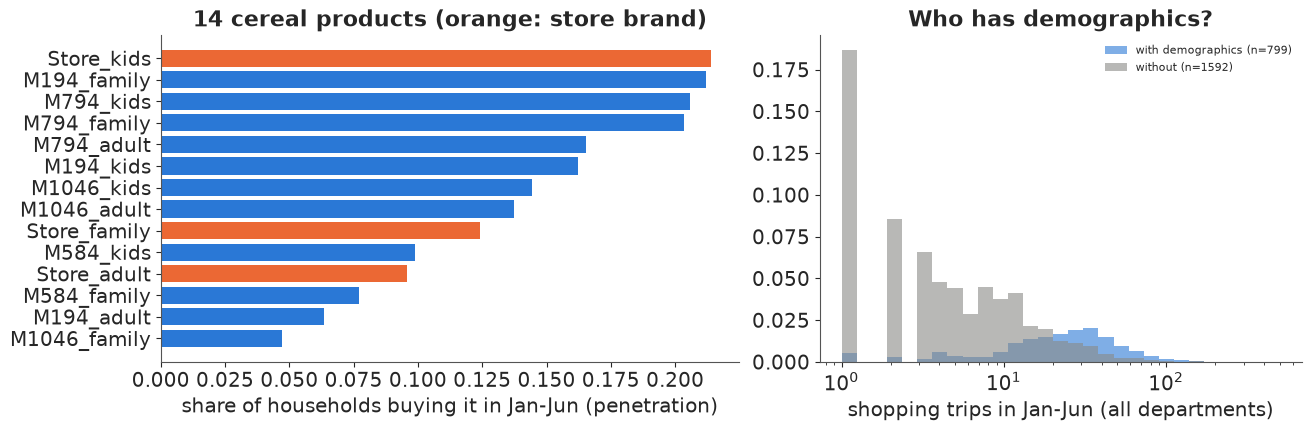

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), width_ratios=[1.2, 1])
pen = Y1.mean(0)
order = np.argsort(pen)
col = [ORANGE if p.startswith("Store") else BLUE for p in PRODUCTS]
a1.barh(np.array(PRODUCTS)[order], pen[order], color=np.array(col)[order])
a1.set_xlabel("share of households buying it in Jan-Jun (penetration)")
a1.set_title("14 cereal products (orange: store brand)")
for flag, colr, lab in [(has_demo, BLUE, "with demographics"), (~has_demo, GREY, "without")]:
    a2.hist(h1["trips"][flag], bins=np.geomspace(1, 500, 30), alpha=0.6, color=colr, density=True,
            label=f"{lab} (n={flag.sum()})")
a2.set_xscale("log")
a2.set_xlabel("shopping trips in Jan-Jun (all departments)")
a2.set_title("Who has demographics?")
a2.legend(fontsize=8);

In [5]:
summary = pd.DataFrame({
    "households": [has_demo.sum(), (~has_demo).sum()],
    "median trips": [np.median(h1["trips"][has_demo]), np.median(h1["trips"][~has_demo])],
    "bought any cereal": [(Y1[has_demo].sum(1) > 0).mean(), (Y1[~has_demo].sum(1) > 0).mean()],
    "cereals bought (mean)": [Y1[has_demo].sum(1).mean(), Y1[~has_demo].sum(1).mean()],
}, index=["with demographics", "without"]).round(2)
summary

,households,median trips,bought any cereal,cereals bought (mean)
with demographics,799,38.0,0.82,2.94
without,1592,13.0,0.54,1.46


The two sources do not overlap at random. Households that filled in the demographic questionnaire
shop about three times as often (median 38 trips in six months against 13), 82% of them bought some
cereal against 54%, and they bought twice as many different cereals. Anything
learned only from the households with demographics describes the **keen shoppers**; anything that
simply drops the other two thirds wastes most of the panel. Section 4 deals with this.

---
# 2 · Raw co-purchase: why everything looks related

The obvious first analysis of an incidence table is **co-purchase lift**: how much more often two
products are bought by the same household than if households chose them independently,

$$\text{lift}_{ij} = \frac{P(\text{bought } i \text{ and } j)}{P(\text{bought } i)\,P(\text{bought } j)}.$$

raw lift: min 1.06, median 1.96, max 4.13


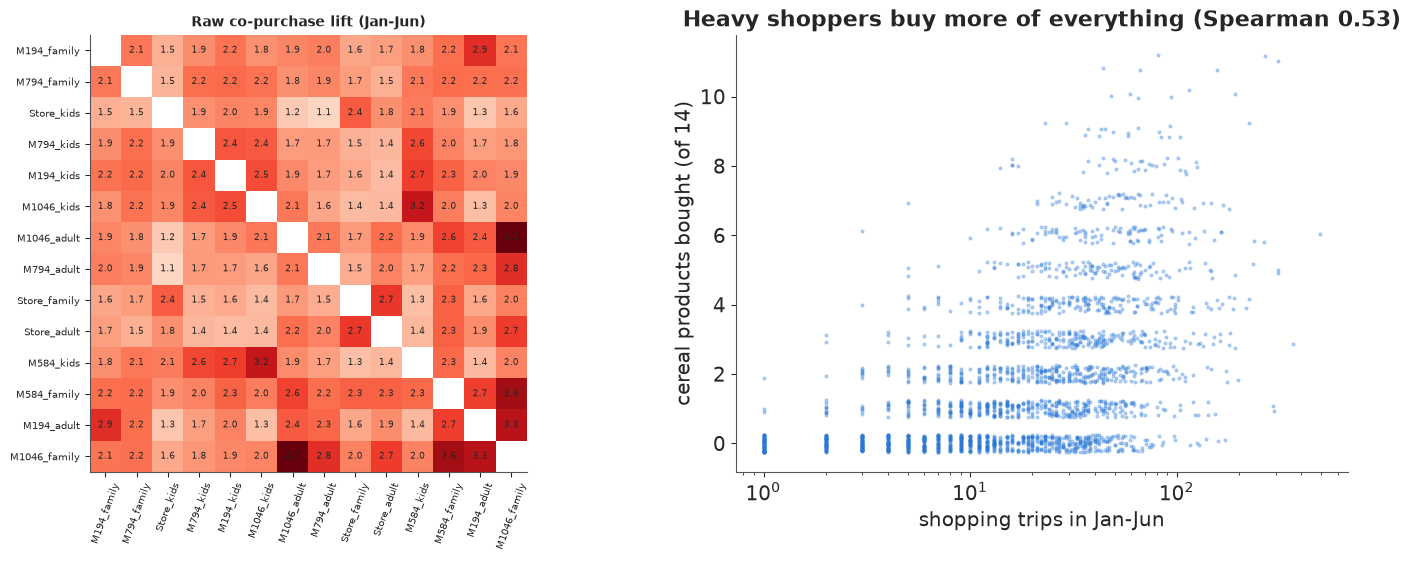

In [6]:
co = (Y1.T @ Y1) / H
lift_raw = co / np.outer(pen, pen)
np.fill_diagonal(lift_raw, np.nan)


def heat(ax, M, title, cmap="RdBu_r", vmin=None, vmax=None, fmt="{:.1f}", center=None):
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax)
    for i in range(J):
        for j in range(J):
            if i != j and np.isfinite(M[i, j]):
                ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center", fontsize=6.5)
    ax.set_xticks(range(J), PRODUCTS, rotation=70, fontsize=7.5)
    ax.set_yticks(range(J), PRODUCTS, fontsize=7.5)
    ax.set_title(title, fontsize=10)
    return im


fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.5), width_ratios=[1.15, 1])
heat(a1, lift_raw, "Raw co-purchase lift (Jan-Jun)", cmap="Reds", vmin=0.5, vmax=4)
n_bought = Y1.sum(1)
jit = rng.uniform(-0.25, 0.25, H)
a2.scatter(h1["trips"], n_bought + jit, s=4, alpha=0.3, color=BLUE)
a2.set_xscale("log")
a2.set_xlabel("shopping trips in Jan-Jun")
a2.set_ylabel("cereal products bought (of 14)")
r = stats.spearmanr(h1["trips"], n_bought).statistic
a2.set_title(f"Heavy shoppers buy more of everything (Spearman {r:.2f})");
print(f"raw lift: min {np.nanmin(lift_raw):.2f}, median {np.nanmedian(lift_raw):.2f}, "
      f"max {np.nanmax(lift_raw):.2f}")

**Every** pair has lift above 1. Read naively, every cereal is bought "with" every other one - a
market without structure, or a market of complements. The right panel says why: households differ
enormously in how much they shop (from one trip to hundreds), and a household that shops a lot buys
more cereals of every kind. Products share heavy buyers, and lift measures that first. It is the
incidence-table version of E84's lesson that aggregate switching mixes up several things; here the
confounder is **volume**.

Lift also cannot separate two further sources of co-purchase that matter for market structure:
households that **like similar products** (a submarket), and households with **several people who want
different cereals** (the kids' cereal and the adults' cereal bought on the same trip - complements at
the household level). We will be able to remove volume; the second distinction stays out of reach of
incidence data, and section 6 comes back to it.

---
# 3 · A ladder of models

Each household-product cell is a Bernoulli outcome. Build up its log-odds piece by piece:

$$\operatorname{logit} P(y_{hj} = 1) = \alpha_j + \kappa_j x_h + a_h + \boldsymbol{\lambda}_j^\top \mathbf{z}_h$$

* $\alpha_j$: product $j$'s baseline penetration;
* $\kappa_j x_h$: **shopping activity** ($x_h$ = standardised log trips), with a product-specific slope -
  the second data source;
* $a_h \sim N(0, \tau)$: the household's **category propensity** - how much cereal it buys beyond what
  its activity predicts (some households eat a lot of cereal, some none);
* $\boldsymbol{\lambda}_j^\top \mathbf{z}_h$: the **choice map** of E84, now for incidence. Household
  $h$ sits at $\mathbf{z}_h \sim N(0, I_K)$, product $j$ has loading $\boldsymbol\lambda_j$, and products
  whose loadings point the same way are bought by the same households. The loadings are centred across
  products, so the map describes **which** cereals a household buys, while $a_h$ and $x_h$ describe
  **how many**.

It is an item-response (or latent-space) model for a binary matrix, the incidence analogue of Elrod's
(1988) choice map. We fit the rungs on January-June and keep July-December for testing. The functions
below take the data as arguments, because section 4 refits on a subset of households.

In [7]:
DEMOS = ["kids", "two_adults", "log_income", "age"]
AGE_MID = {"19-24": 21.5, "25-34": 29.5, "35-44": 39.5, "45-54": 49.5, "55-64": 59.5, "65+": 70.0}


def income_mid(s):
    if pd.isna(s):
        return np.nan
    if s == "Under 15K":
        return 10.0
    if s == "250K+":
        return 275.0
    lo, hi = s.replace("K", "").split("-")
    return (float(lo) + float(hi)) / 2


W_raw = pd.DataFrame({
    "kids": d["kids_count"].isin(["1", "2", "3+"]).astype(float),
    "two_adults": d["household_comp"].astype(str).str.startswith("2").astype(float),
    "log_income": np.log(d["income"].map(income_mid)),
    "age": d["age"].map(AGE_MID) / 10,
}, index=hh)
W_raw[~has_demo] = np.nan
W = ((W_raw - W_raw.mean()) / W_raw.std()).fillna(0.0).to_numpy()   # standardised; 0 when missing
print(W_raw[has_demo].describe().round(2).loc[["mean", "std"]])


def choice_model(Y, x, K=2, propensity=True, activity=True, centred=True, W=None, miss=None):
    """Bernoulli-logit factor model for a household x product 0/1 table.

    W (households x demographics, 0 where missing) and miss (bool) put demographics into the prior
    means of the propensity a_h and of the map position z_h."""
    n = Y.shape[0]
    coords = {"product": PRODUCTS, "hh": np.arange(n), "dim": np.arange(K), "demo": DEMOS}
    with pm.Model(coords=coords) as m:
        eta = pm.Normal("alpha", -2, 2, dims="product")
        if activity:
            eta = eta + pm.Normal("kappa", 0.5, 1, dims="product") * x[:, None]
        if propensity:
            mu_a = 0.0
            if W is not None:
                mu_a = W @ pm.Normal("g_a", 0, 1, dims="demo")
                if miss is not None:
                    mu_a = mu_a + pm.Normal("g_a_missing", 0, 1) * miss
            tau = pm.HalfNormal("tau", 1.5)
            a = pm.Deterministic("a", mu_a + tau * pm.Normal("a_raw", 0, 1, dims="hh"), dims="hh")
            eta = eta + a[:, None]
        if K:
            raw = pm.Normal("raw_loadings", 0, 1.5, dims=("product", "dim"))
            Lam = pm.Deterministic("Lambda", raw - raw.mean(axis=0) if centred else raw,
                                   dims=("product", "dim"))
            mu_z = 0.0
            if W is not None:
                mu_z = W @ pm.Normal("Gamma", 0, 1, dims=("demo", "dim"))
                if miss is not None:
                    mu_z = mu_z + miss[:, None] * pm.Normal("Gamma_missing", 0, 1, dims="dim")
            z = pm.Deterministic("z", mu_z + pm.Normal("z_raw", 0, 1, dims=("hh", "dim")), dims=("hh", "dim"))
            eta = eta + z @ Lam.T
        pm.Bernoulli("y", logit_p=eta, observed=Y)
    return m


def fit(model, draws=1000):
    t0 = time.time()
    keep = [v.name for v in model.free_RVs + model.deterministics
            if v.name not in ("a_raw", "z_raw", "raw_loadings")]
    with model:
        idata = pm.sample(draws=draws, random_seed=RANDOM_SEED, var_names=keep)
    ss = idata.sample_stats
    print(f"sampled in {time.time() - t0:.0f} s ({idata.posterior.attrs.get('tuning_steps')} warm-up "
          f"steps, nutpie); divergences {int(ss['diverging'].sum())}; max tree depth {int(ss['depth'].max())}")
    return idata

      kids  two_adults  log_income   age
mean  0.36        0.56        3.91  4.45
std   0.48        0.50        0.75  1.27


## 3.1 · Activity and propensity

Priors: baselines Normal(-2, 2) on the log-odds scale (penetrations between about 0.2% and 90%);
activity slopes Normal(0.5, 1); propensity scale HalfNormal(1.5). First rung: activity and propensity,
no map.

In [8]:
fits = {}
fits["activity + propensity"] = fit(choice_model(Y1, x1, K=0), draws=500)
az.summary(fits["activity + propensity"], var_names=["tau", "kappa"], round_to=2).iloc[:5]

sampled in 21 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,1.02,0.03,0.96,1.07,413.85,608.15,1.0,0.0,0.0
kappa[M194_family],1.05,0.08,0.93,1.17,1187.44,1350.75,1.0,0.0,0.0
kappa[M794_family],0.94,0.07,0.83,1.06,1432.46,1422.29,1.0,0.0,0.0
kappa[Store_kids],0.99,0.07,0.87,1.10,1285.64,1166.41,1.0,0.0,0.0
kappa[M794_kids],1.04,0.08,0.91,1.16,1102.45,1233.00,1.0,0.0,0.0


A household with one standard deviation more (log) trips has about $e^{1} \approx 2.7$ times the odds of
buying any given cereal, and households differ in cereal propensity with a standard deviation of about
1 on the log-odds scale beyond that. Short sampling runs (500 draws) are enough for the comparison fits;
the main model gets the default 1,000.

## 3.2 · A choice map that measures volume

Now the tempting shortcut: a two-dimensional factor model fitted to the 0/1 table directly, without
the activity and propensity terms and without centring the loadings - which is what a plain factor
analysis or latent-space model of an incidence table does.

In [9]:
fits["naive map"] = fit(choice_model(Y1, x1, K=2, propensity=False, activity=False, centred=False),
                        draws=500)
L_naive = fits["naive map"].posterior["Lambda"].to_numpy().reshape(-1, J, 2)


def align(L, iters=5):
    """Rotate every draw of the loadings (S, J, K) onto a common reference (generalised Procrustes,
    as in E84), then turn the mean onto its principal axes. For display only."""
    ref = L[0]
    for _ in range(iters):
        U, _, Vt = np.linalg.svd(np.einsum("sjk,jl->skl", L, ref))
        R = U @ Vt
        ref = np.einsum("sjk,skl->jl", L, R) / len(L)
    _, _, Vt = np.linalg.svd(ref, full_matrices=False)
    out = np.einsum("sjk,skl,lm->sjm", L, R, Vt.T)
    return out * np.sign(np.median(out, 0).sum(0) + 1e-9)


Lp = align(L_naive)
print("naive map, first principal axis of the loadings (posterior median per product):")
print(pd.Series(np.median(Lp[:, :, 0], 0), PRODUCTS).round(2).to_string())
z_naive = fits["naive map"].posterior["z"].to_numpy().reshape(-1, H, 2)
volume_score = np.einsum("shk,sk->sh", z_naive, L_naive.sum(1)).mean(0)   # sum over products of the map term
print(f"correlation across households of the map's total contribution with log trips: "
      f"{np.corrcoef(volume_score, x1)[0, 1]:.2f}")

sampled in 34 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5
naive map, first principal axis of the loadings (posterior median per product):
M194_family     1.64
M794_family     1.69
Store_kids      1.01
M794_kids       1.86
M194_kids       1.86
M1046_kids      1.69
M1046_adult     1.40
M794_adult      1.25
Store_family    0.89
Store_adult     0.94
M584_kids       1.61
M584_family     1.54
M194_adult      1.30
M1046_family    1.67
correlation across households of the map's total contribution with log trips: 0.52


Every product loads **positively** on the first axis (0.9 to 1.9): the map's main dimension is "this
household buys a lot of cereal", and its total contribution correlates 0.5 with the number of trips. The structure we care
about is squeezed into whatever is left. (The raw loadings also had r_hat above 2: the rotation problem
of E84 is back. We use only rotation-invariant summaries until section 6 aligns the draws.)

## 3.3 · The choice map with activity and propensity

With $x_h$ and $a_h$ taking care of volume and the loadings centred, the map is free to describe
**which** cereals households buy.

sampled in 41 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


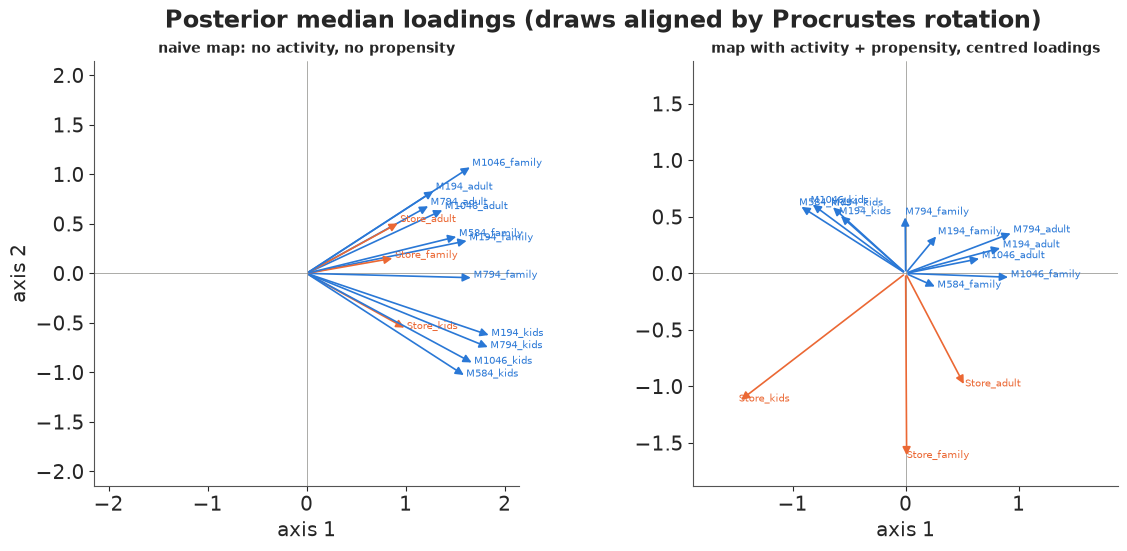

In [10]:
fits["map K=2"] = fit(choice_model(Y1, x1, K=2), draws=500)
Lp2 = align(fits["map K=2"].posterior["Lambda"].to_numpy().reshape(-1, J, 2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for ax, L, title in [(axes[0], Lp, "naive map: no activity, no propensity"),
                     (axes[1], Lp2, "map with activity + propensity, centred loadings")]:
    m = np.median(L, 0)
    for j, p in enumerate(PRODUCTS):
        colr = ORANGE if p.startswith("Store") else BLUE
        ax.annotate("", m[j], (0, 0), arrowprops=dict(arrowstyle="-|>", color=colr, lw=1.2))
        ax.annotate(p, m[j], fontsize=7.5, color=colr)
    lim = 1.15 * np.abs(np.vstack([m, [[0, 0]]])).max()
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.axhline(0, color=GREY, lw=0.5)
    ax.axvline(0, color=GREY, lw=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("axis 1")
axes[0].set_ylabel("axis 2")
fig.suptitle("Posterior median loadings (draws aligned by Procrustes rotation)");

On the left, a fan of arrows pointing one way: volume. On the right, the products spread out in
different directions - the store-brand cereals, the national kids' cereals and the national adult and
family cereals each take their own direction (section 6 makes this precise). That is market structure. Section 5 checks which version predicts the next six
months better.

---
# 4 · Adding demographics without throwing households away

Demographics enter as the **prior mean** of where a household sits:

$$a_h \sim N(\mathbf{g}^\top \mathbf{w}_h + g_0 m_h,\; \tau^2), \qquad
  \mathbf{z}_h \sim N(\Gamma^\top \mathbf{w}_h + \boldsymbol\delta\, m_h,\; I_K),$$

with $\mathbf{w}_h$ = standardised kids (0/1), two adults (0/1), log income and age of the household
head, and $m_h = 1$ when the household has **no** demographics (then $\mathbf{w}_h = 0$). Three
consequences:

* Households **with** demographics get an informed prior; their purchases still decide where they end
  up.
* Households **without** demographics still inform the map, the loadings and everything else; they
  only lack the informed prior. Nothing is imputed.
* The indicator coefficients ($g_0$, $\boldsymbol\delta$) let the households without demographics
  differ systematically from those with - which section 1 says they do. Leaving the indicator out
  would treat them as average members of the questionnaire group.

This assumes that, *given the indicator*, the households without demographics are like the others
in how demographics relate to tastes - an untestable assumption, but much weaker than "missing at
random". We use three dimensions (section 5 shows why).

In [11]:
miss = ~has_demo
fits["map K=3 + demographics"] = fit(choice_model(Y1, x1, K=3, W=W, miss=miss.astype(float)))
idata_main = fits["map K=3 + demographics"]
az.summary(idata_main, var_names=["tau", "g_a", "g_a_missing"], round_to=2)

sampled in 73 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,1.19,0.04,1.13,1.25,897.19,1551.97,1.0,0.0,0.0
g_a[kids],0.14,0.05,0.06,0.23,1832.10,2467.26,1.0,0.0,0.0
g_a[two_adults],0.09,0.06,0.01,0.18,1753.48,2000.05,1.0,0.0,0.0
g_a[log_income],0.11,0.05,0.03,0.19,1675.43,2087.52,1.0,0.0,0.0
g_a[age],-0.15,0.05,-0.24,-0.07,1863.14,2214.62,1.0,0.0,0.0
g_a_missing,-0.38,0.07,-0.50,-0.26,957.64,1315.76,1.0,0.0,0.0


Households with kids, two adults and higher income buy a little more cereal, older households a
little less. The clearest number is the missing-data indicator: households **without demographics have
lower cereal propensity** (about -0.4 on the log-odds scale, after allowing for their fewer trips). The
questionnaire non-responders really are different, and the model now knows it.

## 4.1 · The alternative: complete cases only

The common shortcut is to analyse only the 799 households with demographics. Fit the same model to
them:

In [12]:
fits["complete cases, K=3 + demographics"] = fit(
    choice_model(Y1[has_demo], x1[has_demo], K=3, W=W[has_demo]), draws=500)

sampled in 16 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


We compare the two in section 5 (prediction) and section 6 (how precisely the market structure is
estimated).

---
# 5 · Testing on the next six months

The July-December table is a genuinely new data source for the same households: different trips,
different promotions, new products tried. For each household we score its **whole row** of 14 0/1
outcomes, $\log \frac1S \sum_s \prod_j p(y^{(2)}_{hj} \mid \theta_s)$, using the household's own
posterior $a_h$ and $\mathbf{z}_h$ from January-June and its July-December trips. Higher is better;
differences are summed over the same households, with standard errors from the per-household
differences.

In [13]:
fits["map K=1"] = fit(choice_model(Y1, x1, K=1), draws=500)
fits["map K=4"] = fit(choice_model(Y1, x1, K=4), draws=500)
fits["map K=3"] = fit(choice_model(Y1, x1, K=3), draws=500)


def logit_wave2(idata, rows=None, max_draws=500):
    """Log-odds for July-December, (S, households in both waves, J), from at most max_draws draws.

    rows: positions (within the fitted households) of the households to predict, aligned with Y2."""
    p = idata.posterior
    p = p.isel(draw=slice(None, None, max(1, p.sizes["chain"] * p.sizes["draw"] // max_draws)))
    S = p.sizes["chain"] * p.sizes["draw"]
    sel = np.flatnonzero(has2) if rows is None else rows
    xs = x2 if rows is None else x2_cc
    eta = np.broadcast_to(p["alpha"].to_numpy().reshape(S, 1, J), (S, len(sel), J)).copy()
    if "kappa" in p:
        eta += p["kappa"].to_numpy().reshape(S, 1, J) * xs[None, :, None]
    if "a" in p:
        eta += p["a"].to_numpy().reshape(S, -1)[:, sel, None]
    if "Lambda" in p:
        L = p["Lambda"].to_numpy().reshape(S, J, -1)
        z = p["z"].to_numpy().reshape(S, -1, L.shape[-1])[:, sel]
        eta += np.einsum("shk,sjk->shj", z, L)
    return eta


def household_elpd(eta, Y):
    ll = (Y * -np.logaddexp(0, -eta) + (1 - Y) * -np.logaddexp(0, eta)).sum(-1)   # (S, households)
    return special.logsumexp(ll, axis=0) - np.log(ll.shape[0])


def compare(scores, base):
    rows = []
    for k, s in scores.items():
        dlt = s - scores[base]
        rows.append(dict(model=k, elpd=s.sum(), diff=dlt.sum(), se_diff=dlt.std() * np.sqrt(len(dlt))))
    return pd.DataFrame(rows).set_index("model").round(1)


order = ["activity + propensity", "naive map", "map K=1", "map K=2", "map K=3", "map K=4",
         "map K=3 + demographics"]
scores = {k: household_elpd(logit_wave2(fits[k]), Y2) for k in order}
loadings = {k: fits[k].posterior["Lambda"].to_numpy() for k in ["map K=2", "map K=4"]}
for k in ["naive map", "map K=1", "map K=2", "map K=4"]:
    del fits[k]                                   # keep memory down: only their loadings are needed now
compare(scores, base="activity + propensity")

sampled in 45 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


sampled in 49 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


sampled in 49 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


,elpd,diff,se_diff
model,,,
activity + propensity,-11447.3,0.0,0.0
naive map,-11333.1,114.2,42.4
map K=1,-11092.7,354.6,27.7
map K=2,-10810.3,637.0,40.9
map K=3,-10741.2,706.1,44.7
map K=4,-10703.7,743.6,48.3
map K=3 + demographics,-10726.3,721.0,45.1


* Activity and propensity alone are the baseline. The **naive map** improves on it by about 115 nats
  (it captures volume, after all), but the proper maps beat the baseline by 350-740.
* The map keeps paying for extra dimensions: K = 1 to 2 gains about 280 nats, 2 to 3 about 70 and 3 to
  4 about 40 on 2,340 households. Fourteen products have more
  than three dimensions of taste; we use **three** as the working model and check in section 6 that the
  fourth does not change the structure we report.
* **Demographics add little**: compare the K = 3 maps with and without them:

In [14]:
dlt = scores["map K=3 + demographics"] - scores["map K=3"]
in_both = has_demo[has2]
print(f"demographics vs none (K=3): {dlt.sum():.1f} +- {dlt.std() * np.sqrt(len(dlt)):.1f} nats overall; "
      f"{dlt[in_both].sum():.1f} on the {in_both.sum()} households with demographics, "
      f"{dlt[~in_both].sum():.1f} on the {(~in_both).sum()} without")

demographics vs none (K=3): 14.9 +- 9.7 nats overall; 21.2 on the 799 households with demographics, -6.4 on the 1541 without


Overall the gain is small and uncertain (under 1.5 standard errors). It comes, as it should, from the
households that have demographics (about +21 nats on 799 households); for the others the slightly
different fit costs a few nats. Once you have seen what a household bought for six months,
knowing its age and income adds little about what it will buy next. That is a classic finding in
marketing (demographics explain a small part of brand choice); section 7 measures it directly.

Now the complete-case model, scored on the same 783 households with demographics that are in both
waves:

In [15]:
cc_rows = np.flatnonzero(has2[has_demo])           # positions within the complete-case fit
x2_cc = (np.log(h2["trips"].to_numpy()[has_demo][has2[has_demo]]) - x_mean) / x_sd
Y2_cc = h2[PRODUCTS].to_numpy()[has_demo][has2[has_demo]].astype(int)
full_rows = np.flatnonzero(has2 & has_demo)
s_cc = household_elpd(logit_wave2(fits["complete cases, K=3 + demographics"], rows=cc_rows), Y2_cc)
eta_full = logit_wave2(fits["map K=3 + demographics"])[:, in_both]
s_full = household_elpd(eta_full, Y2_cc)
dlt = s_full - s_cc
print(f"all households vs complete cases, scored on the {len(dlt)} households with demographics: "
      f"{dlt.sum():.1f} +- {dlt.std() * np.sqrt(len(dlt)):.1f} nats")

all households vs complete cases, scored on the 799 households with demographics: -1.6 +- 8.0 nats


For predicting these households' own next six months it makes no detectable difference: their own
purchases dominate their predictions either way. Where the other 1,592 households matter is the market
structure itself, which section 6.4 shows.

---
# 6 · The market structure: shared clientele

## 6.1 · What the incidence map can measure

Without prices we cannot compute diversion ratios: nothing in the data says what happens when a price
changes. What the map measures is **shared clientele**: the correlation, across households, of the
taste for product $i$ and the taste for product $j$, net of activity and overall cereal propensity,

$$\rho_{ij} = \frac{(\Lambda\Lambda^\top)_{ij}}{\sqrt{(\Lambda\Lambda^\top)_{ii}\,(\Lambda\Lambda^\top)_{jj}}}.$$

It is rotation-invariant, so it is identified even though the loadings are not, and it is the
incidence-data version of a submarket: products with high $\rho$ are bought by the same households.
Read it with one caveat from section 2 in mind: in a family, a high $\rho$ can also mean that different
members want different cereals.

In [16]:
def shared_clientele(idata_or_loadings):
    L = idata_or_loadings
    if not isinstance(L, np.ndarray):
        L = L.posterior["Lambda"].to_numpy()
    L = L.reshape(-1, J, L.shape[-1])
    C = np.einsum("sjk,sik->sji", L, L)
    sd = np.sqrt(np.einsum("sjj->sj", C))
    return C / sd[:, :, None] / sd[:, None, :]


rho = shared_clientele(idata_main)
rho_med = np.median(rho, 0)
iu = np.triu_indices(J, 1)
for other in ["map K=4", "map K=2"]:
    r_o = np.median(shared_clientele(loadings[other]), 0)
    print(f"shared clientele, K=3 + demographics vs {other}: correlation of the 91 pairs "
          f"{np.corrcoef(rho_med[iu], r_o[iu])[0, 1]:.2f}")

shared clientele, K=3 + demographics vs map K=4: correlation of the 91 pairs 0.98
shared clientele, K=3 + demographics vs map K=2: correlation of the 91 pairs 0.93


The three-dimensional structure is almost exactly the four-dimensional one (and close to the
two-dimensional one): the extra dimensions improve predictions of individual households more than they
change which products share buyers.

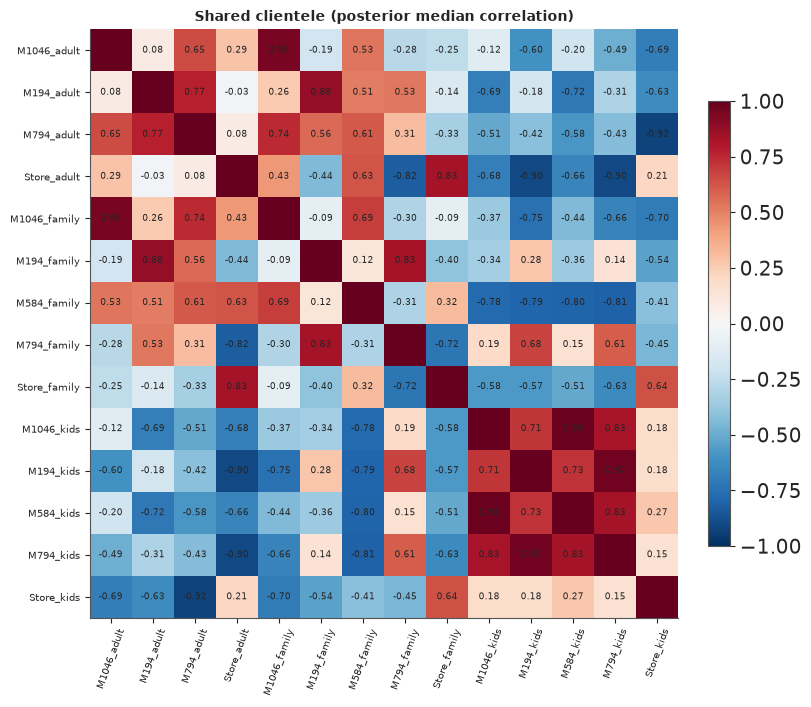

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
srt = np.argsort([p.split("_")[1] + p for p in PRODUCTS])          # group by segment for display
im = heat(ax, rho_med[np.ix_(srt, srt)], "Shared clientele (posterior median correlation)",
          cmap="RdBu_r", vmin=-1, vmax=1, fmt="{:.2f}")
ax.set_xticks(range(J), np.array(PRODUCTS)[srt], rotation=70, fontsize=7.5)
ax.set_yticks(range(J), np.array(PRODUCTS)[srt], fontsize=7.5)
fig.colorbar(im, ax=ax, shrink=0.75);

## 6.2 · Manufacturer first, or segment first?

Average $\rho$ over three kinds of pairs - same manufacturer in different segments, same segment from
different manufacturers, and neither - per posterior draw:

In [18]:
maker = np.array([p.split("_")[0] for p in PRODUCTS])
seg = np.array([p.split("_")[1] for p in PRODUCTS])
same_m = (maker[:, None] == maker[None, :])[iu]
same_s = (seg[:, None] == seg[None, :])[iu]
pairs = rho[:, iu[0], iu[1]]
kinds = {"same manufacturer, other segment": same_m & ~same_s,
         "same segment, other manufacturer": same_s & ~same_m,
         "neither": ~same_m & ~same_s}
store = (maker == "Store")
kinds["store brand with store brand"] = (store[:, None] & store[None, :])[iu]
kinds["national manufacturer, own other segment"] = same_m & ~same_s & ~(store[:, None] & store[None, :])[iu]
avg = {k: pairs[:, v].mean(1) for k, v in kinds.items()}
print(pd.DataFrame({k: q(v) for k, v in avg.items()}, index=["5%", "50%", "95%"]).T.to_string())
print(f"P(segment pairs share more clientele than manufacturer pairs) = "
      f"{(avg['same segment, other manufacturer'] > avg['same manufacturer, other segment']).mean():.2f}")

                                            5%   50%   95%
same manufacturer, other segment          0.14  0.22  0.29
same segment, other manufacturer          0.24  0.29  0.35
neither                                  -0.32 -0.30 -0.28
store brand with store brand              0.44  0.56  0.66
national manufacturer, own other segment  0.03  0.11  0.20
P(segment pairs share more clientele than manufacturer pairs) = 0.84


Products in the **same segment** from different manufacturers share more clientele (0.29) than a
manufacturer's products in different segments (0.22; posterior probability 0.84 that segment wins), and
pairs with nothing in common share the least (negative: households that buy one tend not to buy the
other). Splitting the manufacturer pairs shows why the comparison is close: the **store brand's**
kids', family and adult cereals share clientele strongly (0.56), while a *national* manufacturer's
products in different segments barely do (0.11). Households are loyal to the store brand as a brand;
for national brands they shop by segment.

## 6.3 · A tree with posterior support

As in E84: cluster the products using $1 - \rho$ as a distance (average linkage) in every posterior
draw, and print on each branch the share of draws in which that group appears.

['M1046_kids', 'M584_kids']: support 93%
['M194_kids', 'M794_kids']: support 84%
['M1046_adult', 'M1046_family']: support 77%
['M194_adult', 'M194_family']: support 47%
['Store_adult', 'Store_family']: support 74%
['M1046_kids', 'M194_kids', 'M584_kids', 'M794_kids']: support 82%
['M1046_adult', 'M1046_family', 'M794_adult']: support 31%
['M194_adult', 'M194_family', 'M794_family']: support 35%
['M1046_adult', 'M1046_family', 'M584_family', 'M794_adult']: support 26%
['Store_adult', 'Store_family', 'Store_kids']: support 62%
['M1046_adult', 'M1046_family', 'M194_adult', 'M194_family', 'M584_family', 'M794_adult', 'M794_family']: support 36%
['M1046_adult', 'M1046_family', 'M194_adult', 'M194_family', 'M584_family', 'M794_adult', 'M794_family', 'Store_adult', 'Store_family', 'Store_kids']: support 24%


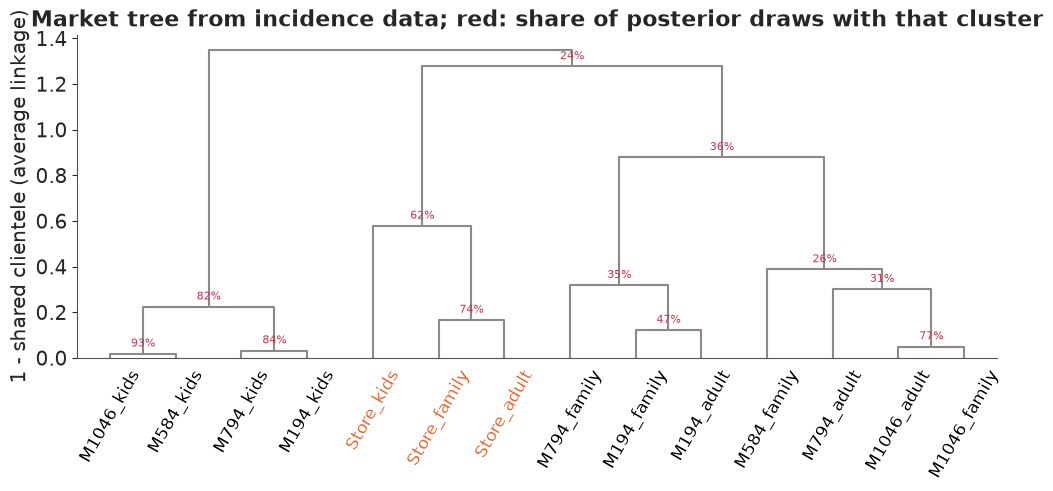

In [19]:
def tree(R):
    dist = 1 - R
    np.fill_diagonal(dist, 0)
    return hierarchy.linkage(np.clip(dist[iu], 0, None), method="average")


def clusters(Z):
    out, members = [], {i: frozenset([i]) for i in range(J)}
    for n, (a, b, *_) in enumerate(Z):
        members[J + n] = members[int(a)] | members[int(b)]
        out.append(members[J + n])
    return out


Z_med = tree(rho_med)
draw_sets = [set(clusters(tree(rho[s]))) for s in range(0, len(rho), 4)]
support = [np.mean([c in ds for ds in draw_sets]) for c in clusters(Z_med)]
fig, ax = plt.subplots(figsize=(10, 4.8))
dn = hierarchy.dendrogram(Z_med, labels=PRODUCTS, ax=ax, color_threshold=0, above_threshold_color=GREY,
                          leaf_rotation=60)
tops = [(dc[1], (ic[1] + ic[2]) / 2) for ic, dc in zip(dn["icoord"], dn["dcoord"])]
for n, (c, sup) in enumerate(zip(clusters(Z_med), support)):
    if len(c) < J:
        x = [xc for hgt, xc in tops if np.isclose(hgt, Z_med[n, 2])][0]
        ax.text(x, Z_med[n, 2] + 0.02, f"{sup:.0%}", ha="center", va="bottom", fontsize=8, color=RED)
        print(f"{sorted(PRODUCTS[i] for i in c)}: support {sup:.0%}")
for lab in ax.get_xticklabels():
    lab.set_color(ORANGE if lab.get_text().startswith("Store") else "k")
ax.set_ylabel("1 - shared clientele (average linkage)")
ax.set_title("Market tree from incidence data; red: share of posterior draws with that cluster");

Two groups are solid: the **national kids' cereals** of all four manufacturers (82% of draws, with
tight pairs inside) and the **store brand's three products** (62%). The national adult and family
cereals form the rest of the tree, but how they group inside is uncertain (supports of 26-47%): these
data say they are not kids' cereals and not store brand, and not much more. So the incidence data give a
market of three submarkets - national kids, national adult/family, store brand - with the last defined
by brand rather than segment. The store brand's kids' cereal sits with the store brand, not with the
other kids' cereals, which matters for the coupon in section 8.

## 6.4 · How much do the extra households buy us?

The complete-case fit estimated the same structure from a third of the households. Compare the width of
the 90% posterior intervals of the 91 shared-clientele correlations:

In [20]:
rho_cc = shared_clientele(fits["complete cases, K=3 + demographics"])
w_all = np.diff(np.quantile(rho, [0.05, 0.95], axis=0), axis=0)[0][iu]
w_cc = np.diff(np.quantile(rho_cc, [0.05, 0.95], axis=0), axis=0)[0][iu]
print(f"90% interval width of shared clientele: all households median {np.median(w_all):.2f}, "
      f"complete cases median {np.median(w_cc):.2f}")
print(f"correlation of the two structures' medians: "
      f"{np.corrcoef(rho_med[iu], np.median(rho_cc, 0)[iu])[0, 1]:.2f}")

90% interval width of shared clientele: all households median 0.46, complete cases median 0.64
correlation of the two structures' medians: 0.94


The complete-case structure has the same shape (correlation 0.94 with the full one) but its intervals
are about 40% wider: two thirds of the information about the market structure sits in households that
never answered the questionnaire. The missing-data indicator lets them contribute without pretending
they look like the questionnaire households.

---
# 7 · What demographics explain

## 7.1 · Effects on which cereals a household buys

$\Gamma$ is rotated along with the map, so it is not identified on its own; but its effect on the
utility of each product, $\Lambda\Gamma^\top$ (a product x demographic matrix), is. Each entry says how
much a one-standard-deviation change in the demographic shifts the log-odds of buying product $j$
**relative to the household's other cereals**.

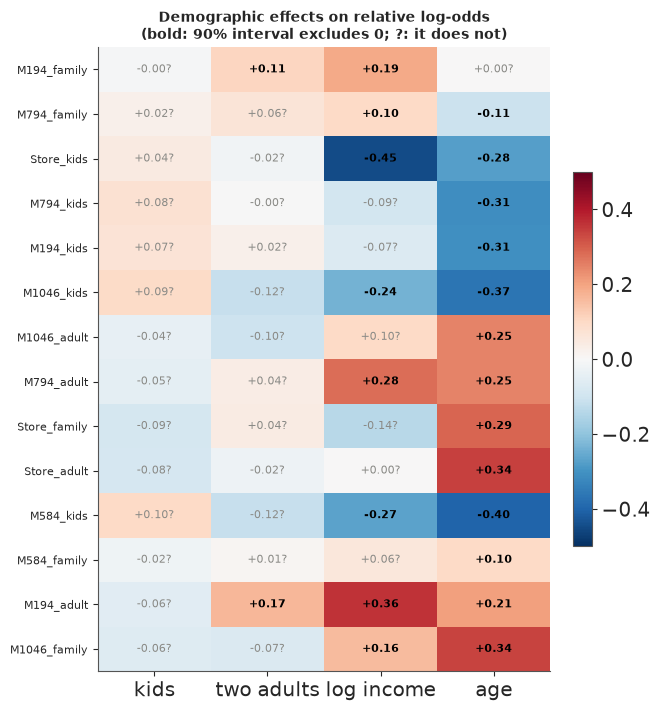

In [21]:
p = idata_main.posterior
L = p["Lambda"].to_numpy().reshape(-1, J, 3)
G = p["Gamma"].to_numpy().reshape(-1, len(DEMOS), 3)
effect = np.einsum("sjk,sdk->sjd", L, G)
med = np.median(effect, 0)
lo, hi = np.quantile(effect, [0.05, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(6.5, 7))
im = ax.imshow(med, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
for j in range(J):
    for k in range(len(DEMOS)):
        sure = lo[j, k] > 0 or hi[j, k] < 0
        ax.text(k, j, f"{med[j, k]:+.2f}" + ("" if sure else "?"), ha="center", va="center", fontsize=8,
                fontweight="bold" if sure else "normal", color="k" if sure else GREY)
ax.set_xticks(range(len(DEMOS)), ["kids", "two adults", "log income", "age"])
ax.set_yticks(range(J), PRODUCTS, fontsize=8)
ax.set_title("Demographic effects on relative log-odds\n(bold: 90% interval excludes 0; ?: it does not)",
             fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.6);

**Age** of the household head does most of the work: younger households lean to the kids' cereals of
every manufacturer, older households to adult and family cereals. **Income** separates the store brand's
kids' cereal (lower income) from the adult cereals of the national brands (higher income). The **kids**
flag adds little once age is known - the two are strongly related, and age is the better-measured of
the two in this file.

## 7.2 · How much of the map do they explain?

In [22]:
z = p["z"].to_numpy().reshape(-1, H, 3)[::4]
mu_z = np.einsum("hd,sdk->shk", W, G[::4])
share = mu_z[:, has_demo].var(axis=1).sum(-1) / z[:, has_demo].var(axis=1).sum(-1)
print(f"share of the variance of households' map positions explained by demographics: {q(share)}")

share of the variance of households' map positions explained by demographics: [0.08 0.11 0.14]


About a tenth. Demographics point in the right directions, but nine tenths of what makes a household
buy the cereals it buys is not in the demographic file. That is why they barely improved predictions for
households whose purchases we have already seen. They matter most where purchase history is missing -
the next section.

---
# 8 · Targeting a trial coupon

The retailer wants households to **try** its store-brand kids' cereal. Candidates are the households
that did not buy it in January-June; the coupon budget covers the top 20% of them. We score each
candidate with each source of information, and then look at what really happened: who bought
`Store_kids` in July-December.

* **activity only**: the independent-products model's view (trips and penetration);
* **demographics only**: what we would know about a household that had just joined the panel - the
  main model's prediction from its demographics and trips alone, integrating over the unseen $a_h$ and
  $\mathbf{z}_h$ (only for households with demographics);
* **purchases + activity**: the K = 3 map without demographics;
* **everything**: the main model.

In [23]:
j_store_kids = PRODUCTS.index("Store_kids")
cand = (Y1[has2, j_store_kids] == 0)
outcome = Y2[cand, j_store_kids]
print(f"candidates: {cand.sum():,} households; {outcome.mean():.1%} of them bought Store_kids in Jul-Dec")


def prob_store_kids(idata):
    return special.expit(logit_wave2(idata)[:, :, j_store_kids]).mean(0)


def prob_from_demographics(idata, n=400):
    """P(buy) for a household known only by demographics and trips: a_h, z_h drawn from their priors."""
    p = idata.posterior
    S = p.sizes["chain"] * p.sizes["draw"]
    idx = np.random.default_rng(1).choice(S, n, replace=False)
    get = lambda v: p[v].to_numpy().reshape(S, *p[v].shape[2:])[idx]
    Wh, Mh = W[has2], miss[has2].astype(float)
    a = (Wh @ get("g_a").T).T + get("g_a_missing")[:, None] * Mh
    a = a + get("tau")[:, None] * rng.normal(size=a.shape)
    zz = np.einsum("hd,sdk->shk", Wh, get("Gamma")) + Mh[None, :, None] * get("Gamma_missing")[:, None, :]
    zz = zz + rng.normal(size=zz.shape)
    eta = (get("alpha")[:, None, j_store_kids] + get("kappa")[:, None, j_store_kids] * x2 + a
           + np.einsum("shk,sk->sh", zz, get("Lambda")[:, j_store_kids]))
    return special.expit(eta).mean(0)


scores_t = {"activity only": prob_store_kids(fits["activity + propensity"]),
            "demographics only": prob_from_demographics(idata_main),
            "purchases + activity": prob_store_kids(fits["map K=3"]),
            "everything": prob_store_kids(idata_main)}


def auc(y, s):
    r = stats.rankdata(s)
    n1 = y.sum()
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * (len(y) - n1))


def capture_at(y, s, frac=0.2):
    top = np.argsort(-s)[: int(frac * len(s))]
    return y[top].sum() / y.sum()


demo_cand = has_demo[has2][cand]
rows = []
for k, s in scores_t.items():
    for grp, sel in [("all candidates", np.ones(cand.sum(), bool)), ("with demographics", demo_cand)]:
        if k == "demographics only" and grp == "all candidates":
            continue
        rows.append(dict(score=k, group=grp, AUC=auc(outcome[sel], s[cand][sel]),
                         **{"triers reached by top 20%": capture_at(outcome[sel], s[cand][sel])}))
pd.DataFrame(rows).set_index(["group", "score"]).round(3)

candidates: 1,832 households; 11.5% of them bought Store_kids in Jul-Dec


AUC  triers reached by top 20%
group             score                                                 
all candidates    activity only         0.646                      0.362
with demographics activity only         0.606                      0.286
                  demographics only     0.634                      0.351
all candidates    purchases + activity  0.684                      0.410
with demographics purchases + activity  0.660                      0.364
all candidates    everything            0.696                      0.433
with demographics everything            0.688                      0.377

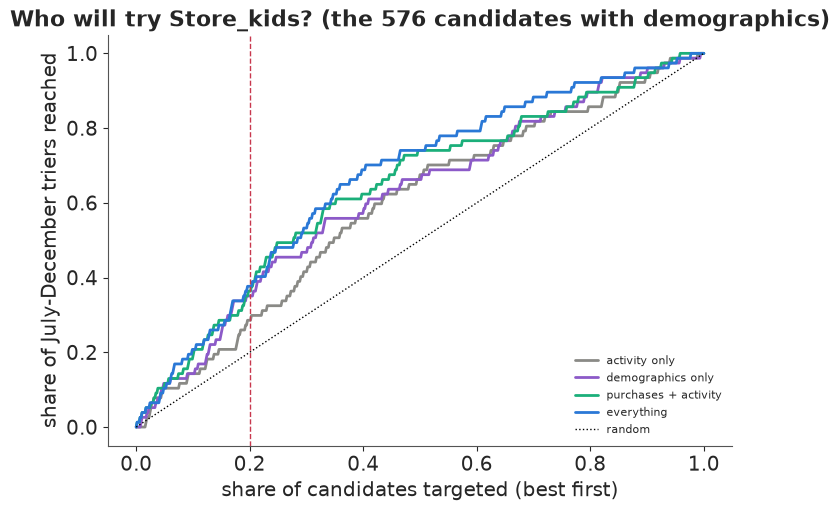

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
sel = demo_cand
y_sel = outcome[sel]
for (k, s), colr in zip(scores_t.items(), [GREY, PURPLE, AQUA, BLUE]):
    o = np.argsort(-s[cand][sel])
    gains = np.concatenate([[0], np.cumsum(y_sel[o]) / y_sel.sum()])
    ax.plot(np.linspace(0, 1, len(gains)), gains, color=colr, label=k, lw=2)
ax.plot([0, 1], [0, 1], color="k", ls=":", lw=1, label="random")
ax.axvline(0.2, color=RED, ls="--", lw=1)
ax.set_xlabel("share of candidates targeted (best first)")
ax.set_ylabel("share of July-December triers reached")
ax.set_title(f"Who will try Store_kids? (the {sel.sum()} candidates with demographics)")
ax.legend(fontsize=8, loc="lower right");

Read the gains chart left to right: the steeper the curve, the more of the households that really did
try the store-brand kids' cereal are reached for a given coupon budget.

* **Across all candidates**, the incidence table (which other cereals a household bought) beats trips
  and penetration alone: AUC 0.68 against 0.65, and the top 20% reaches 41% of the eventual triers
  against 36%. Adding demographics gives the best ranking (0.70, 43%).
* **For the households with demographics**, demographics alone (0.63) come close to purchase history
  (0.66) and clearly beat activity alone (0.61); combining them is best (0.69). Demographics explained
  only a tenth of the map, but the part they explain - younger, lower-income households - is exactly
  the store-brand kids' cereal's clientele. And for a household that has just joined the panel they are
  the only source there is.
* The outcome is noisy: 11.5% of candidates tried the product, and the curves cross at small budgets.
  Differences of a few points of AUC on 576 households are suggestive, not decisive.

---
## Summary

* **An incidence table measures shared clientele, not substitution.** With no prices and no purchase
  sequences it cannot give diversion ratios (E84); it can say which products are bought by the same
  households - and, in families, that can also mean different members wanting different products.
* **Raw co-purchase lift was above 1 for every pair** because heavy shoppers buy more of everything;
  a factor model fitted to the raw table spent its first dimension on volume. Shopping activity (a
  second data source) and a household category propensity remove volume; centred loadings then
  describe *which* cereals households buy.
* **Demographics covered a third of the households and were not missing at random**: questionnaire
  households shopped about three times as often and, given that, still had higher cereal propensity.
  Putting demographics (and a missing indicator) in the *prior mean* of each household's map position
  uses every household. Complete-case analysis predicted its own households about as well, but estimated
  the market structure with 40% wider intervals.
* **Validation on the next six months**: proper maps beat activity-only by 350-740 nats and the naive
  map by far more than it beat the baseline; three to four dimensions were supported, and the
  shared-clientele structure was the same at K = 3 and K = 4 (correlation 0.98).
* **Structure**: three submarkets - national kids' cereals, national adult and family cereals, and the
  store brand across all segments. National brands are bought by segment, the store brand as a brand.
* **Demographics explained about a tenth of the map** (age most, then income) and added little once
  purchases were known. In the coupon targeting they nearly matched purchase history for the households
  that had them, and combining every source gave the best ranking.

## Try it yourself

1. **Counts instead of 0/1.** Many panels also deliver the *number* of purchases per period. Rebuild the
   table with counts (see `tools/build_e85_cereal.py`) and replace the Bernoulli with a negative binomial
   or a hurdle model sharing the same map. Does the structure change, and does it predict July-December
   incidence better?
2. **Fuse the two waves.** Fit one model to both half-years with household positions that drift,
   $\mathbf{z}^{(2)}_h = \mathbf{z}^{(1)}_h + \boldsymbol\epsilon_h$. How stable are households' tastes
   over six months, and does the store brand's clientele grow?
3. **Add a price source.** Weekly average shelf prices per product can be computed from the
   transaction file (`sales_value / quantity`). Use them as product-level covariates of the incidence
   probability in a half-year, or join them to a weekly purchase model, and see whether the
   shared-clientele groups are also the groups with the largest cross-price effects.